# Trabalho de DL - Detector de SPAM (RNN) - G13

### 1. Importar bibliotecas

In [22]:
# Importação das bibliotecas
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAND_SEED = 13 #Em homenagem ao grupo

### 2. Carregar a base

In [23]:
# carrega e arruma a base
!wget -nv -O spam.csv http://www.razer.net.br/datasets/spam.csv

df = pd.read_csv("spam.csv", encoding="ISO-8859-1")

df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
df.columns = ["labels", "data"]
df["b_labels"] = df["labels"].map({"ham": 0, "spam": 1})



2026-07-04 16:21:23 URL:https://www.razer.net.br/datasets/spam.csv [503663/503663] -> "spam.csv" [1]


### 4. Tokenização e criação do vocabulário

In [24]:
texts = df["data"].to_list()
labels = df["b_labels"].values

In [25]:
import re
from collections import Counter

# Função que cria tokens
def tokenize(text):
    text = text.lower()
    # Substitua tudo que casar com padrao por ''
    # Padrão : que não seja letras, numero, _ ou espaço em branco
    text = re.sub(r'[^\w\s]', '', text) 
    return text.split()

tokens = [tokenize(t) for t in texts]

# Cria um dicionario que conta o número de ocorrencia de cada token
counter = Counter()

for t in tokens:
    counter.update(t)

# Cria o vocabulário
vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word in counter:
    vocab[word] = len(vocab)

### 5. Acerta o tamanho das sequências (padding)

In [26]:
def numericalize(text):
    return [
        vocab.get(token, vocab["<UNK>"])
        for token in tokenize(text)
    ]

sequences = [numericalize(t) for t in texts]

In [27]:
# Remove sequencias vazias e mostra as exclusões
filtered_texts = []
filtered_labels = []
indice = 0
for text, label in zip(texts, labels):
    seq = numericalize(text)

    if len(seq) > 0:
        filtered_texts.append(seq)
        filtered_labels.append(label)
    else:
        print(f"Removendo a linha {indice}, com o conteudo: {text}")
    
    indice += 1

Removendo a linha 3374, com o conteudo: :) 
Removendo a linha 4822, com o conteudo: :-) :-)


### 6. Dataset Pytorch

In [28]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx]),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )
        
#dataset = SpamDataset(sequences, labels)
dataset = SpamDataset(filtered_texts, filtered_labels)

### 7. Separa treino/teste e cria o Dataloader

In [29]:
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

# Como as amostras de texto possuem tamanhos diferentes, essa é a forma de fazer padding para que todas
# as amostras possuam o mesmo tamanho na hora da construção do dataloader,
# além disso cada amostra vai conter o tamanho original

def collate_fn(batch):
    texts, labels = zip(*batch)

    lengths = torch.tensor([len(x) for x in texts])

    texts = pad_sequence(
        texts,
        batch_first=True,
        padding_value=vocab["<PAD>"]
    )

    labels = torch.stack(labels)

    return texts, lengths, labels


In [30]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(dataset))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.3,
    stratify=filtered_labels,
    random_state=RAND_SEED
)

train_dataset = torch.utils.data.Subset(dataset, train_idx)
test_dataset = torch.utils.data.Subset(dataset, test_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=len(test_dataset),
    shuffle=False,
    collate_fn=collate_fn
)

In [31]:
# Verificação

# pegar um batch de treino (possue 32 observações que é o tamanho de cada batch definido no dataloader)
batch = next(iter(train_loader))

In [32]:
# cada entrada do batch possui 3 partes: a observação (text com padd), o tamanho da observação (exclui os padds),
# e o label (0 ou 1)
print("Texto com padds:")
print(batch[0][0])

print(f"\nTamanho do texto sem padd: {batch[1][0]}")

print(f"Label: {batch[2][0]}")



Texto com padds:
tensor([2038,  284,  656,  489,    9,  226, 4416, 4417,  103,  418,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])

Tamanho do texto sem padd: 10
Label: 0.0


### 8. Definição do modelo

In [33]:
import torch.nn as nn

class SpamClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        num_layers=1
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        x = self.embedding(x)

        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden, _) = self.lstm(packed)

        out = hidden[-1]

        out = self.fc(out)

        return out.squeeze(1)

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SpamClassifier(
    vocab_size=len(vocab)
).to(device)

### 9. Função de perda e otimizador

In [35]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

### 10. Compila e treina o modelo

In [36]:
epochs = 5

train_losses = []
test_losses = []

train_accs = []
test_accs = []

for epoch in range(epochs):

    #########################
    # TREINAMENTO
    #########################

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for texts, lengths, labels in train_loader:

        texts = texts.long().to(device)
        lengths = lengths.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()

        logits = model(texts, lengths)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    #########################
    # TESTE
    #########################

    model.eval()

    test_loss = 0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for texts, lengths, labels in test_loader:

            texts = texts.long().to(device)
            lengths = lengths.to(device)
            labels = labels.float().to(device)

            logits = model(texts, lengths)

            loss = criterion(logits, labels)

            test_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    test_loss /= len(test_loader)
    test_acc = test_correct / test_total

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Train Loss={train_loss:.4f} "
        f"Train Acc={train_acc:.4f} "
        f"Test Loss={test_loss:.4f} "
        f"Test Acc={test_acc:.4f}"
    )

Epoch 1/5 Train Loss=0.2893 Train Acc=0.9036 Test Loss=0.1294 Test Acc=0.9611
Epoch 2/5 Train Loss=0.0782 Train Acc=0.9761 Test Loss=0.0847 Test Acc=0.9755
Epoch 3/5 Train Loss=0.0351 Train Acc=0.9913 Test Loss=0.0896 Test Acc=0.9743
Epoch 4/5 Train Loss=0.0158 Train Acc=0.9969 Test Loss=0.0896 Test Acc=0.9767
Epoch 5/5 Train Loss=0.0097 Train Acc=0.9974 Test Loss=0.0983 Test Acc=0.9755


### 11. Exibe a perda e a acurácia

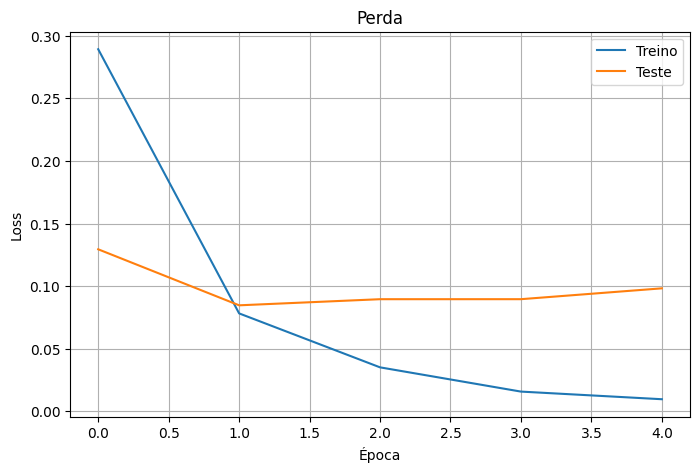

In [37]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Treino')
plt.plot(test_losses, label='Teste')

plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Perda')

plt.legend()
plt.grid()
plt.show()

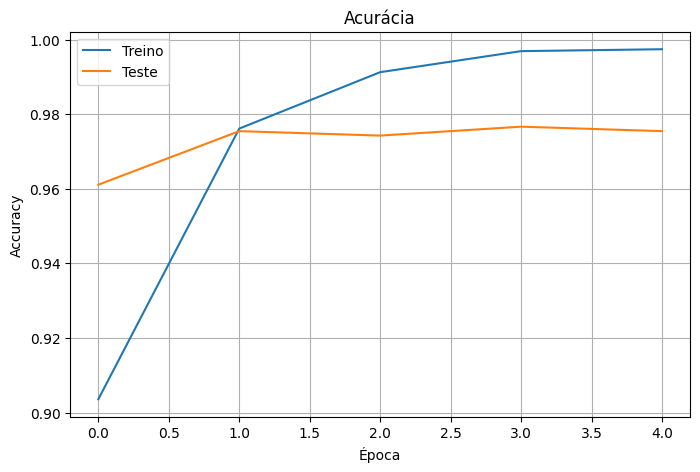

In [38]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label='Treino')
plt.plot(test_accs, label='Teste')

plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Acurácia')

plt.legend()
plt.grid()
plt.show()

### 12. Faz a predição de um dado novo

In [39]:
def predict(text):
    model.eval()

    seq = numericalize(text)
    if len(seq) > 0:
        x = torch.tensor(seq).unsqueeze(0).to(device)
        length = torch.tensor([len(seq)]).to(device)

        with torch.no_grad():
            logits = model(x, length)
            prob = torch.sigmoid(logits)

        return 'SPAM' if prob.item() >= 0.5 else 'OK'
    return 'ERROR'
    

In [40]:
texto = "what time is the meeting"
pred = predict(texto)
print(f"Para o texto: \'{texto}\' eu acho que é {pred}")

Para o texto: 'what time is the meeting' eu acho que é OK


In [41]:
texto = "Is your car dirty? Discover our new product. Free for all. Click the link."
pred = predict(texto)
print(f"Para o texto: \'{texto}\' eu acho que é {pred}")

Para o texto: 'Is your car dirty? Discover our new product. Free for all. Click the link.' eu acho que é SPAM


In [42]:
texto = ":)"
pred = predict(texto)
print(f"Para o texto: \'{texto}\' eu acho que é {pred}")

Para o texto: ':)' eu acho que é ERROR
